# Temporale Analyse NY Parking Violations

In [6]:
import os
for item in sorted(os.environ.items()): print(item)

('ALLUSERSPROFILE', 'C:\\ProgramData')
('APPDATA', 'C:\\Users\\Stephan\\AppData\\Roaming')
('APPLICATION_INSIGHTS_NO_STATSBEAT', 'true')
('CHOCOLATEYINSTALL', 'C:\\ProgramData\\chocolatey')
('CHOCOLATEYLASTPATHUPDATE', '132478278636680458')
('CHROME_CRASHPAD_PIPE_NAME', '\\\\.\\pipe\\crashpad_5988_JQGQLQTBMUWWEVGG')
('CLICOLOR', '1')
('CLICOLOR_FORCE', '1')
('COMMONPROGRAMFILES', 'C:\\Program Files\\Common Files')
('COMMONPROGRAMFILES(X86)', 'C:\\Program Files (x86)\\Common Files')
('COMMONPROGRAMW6432', 'C:\\Program Files\\Common Files')
('COMPUTERNAME', 'LIMMATSTE')
('COMSPEC', 'C:\\WINDOWS\\system32\\cmd.exe')
('COPILOT_OTEL_FILE_EXPORTER_PATH', '\\\\.\\nul')
('DRIVERDATA', 'C:\\Windows\\System32\\Drivers\\DriverData')
('ELECTRON_RUN_AS_NODE', '1')
('FORCE_COLOR', '1')
('FP_NO_HOST_CHECK', 'NO')
('GIT_PAGER', 'cat')
('HOMEDRIVE', 'C:')
('HOMEPATH', '\\Users\\Stephan')
('JPY_INTERRUPT_EVENT', '4216')
('LOCALAPPDATA', 'C:\\Users\\Stephan\\AppData\\Local')
('LOGONSERVER', '\\\\LIMMATST

## Spark Context 

In [16]:
import os

java_home = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.20.101-hotspot"
os.environ["JAVA_HOME"] = java_home
os.environ["PATH"] = os.path.join(java_home, "bin") + os.pathsep + os.environ["PATH"]

from pyspark import SparkContext, SparkConf
from pyspark.sql import SQLContext

if 'sc' in locals() and sc is not None:
    sc.stop()

SparkContext.setSystemProperty('spark.eventLog.enabled', 'false')

conf = SparkConf().setMaster("local[4]").setAppName("Spark_4")
sc = SparkContext(conf=conf)

# Settings Played With
# SparkContext.setSystemProperty('spark.driver.maxResultSize', '8g')
# SparkContext.setSystemProperty('spark.executor.memory', '2g')
# SparkContext.setSystemProperty('spark.executor.cores', '3')
# SparkContext.setSystemProperty('spark.memory.fraction', '0.6')
# ---> no better performance reached so far!!!

sc._conf.getAll()
for item in sorted(sc._conf.getAll()):
    print(item)

print(sc.version)

('spark.app.id', 'local-1789276525759')
('spark.app.name', 'Spark_4')
('spark.app.startTime', '1789276525651')
('spark.app.submitTime', '1789276433864')
('spark.driver.extraJavaOptions', '-Djava.net.preferIPv6Addresses=false -XX:+IgnoreUnrecognizedVMOptions --add-modules=jdk.incubator.vector --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/jdk.internal.ref=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.security.action=ALL-UNNAMED --add-opens=java.base/sun.util.calendar=ALL-UNNAMED --add-opens=java.securit

## Program - NY Parking Violations

- Foocus on timely distribution of Parking Violations
- per Day
- per Time
- combination Day / Time

In [21]:
# Data Import
# -----------
from pathlib import Path

sqlContext = SQLContext(sc)

data_path = Path("data") / "Parking_Violations_Issued_-_Fiscal_Year_2021.csv"
df_full = sqlContext.read.format("csv").option("header", "true").option("inferSchema", "true").load(str(data_path))

In [24]:
# UD-Functions in SQL Context
# ---------------------------
import datetime
import calendar
from pyspark.sql.functions import date_format
from pyspark.sql.functions import udf

# Full written Weekday from date YYYY-MM-DD HH:MM:SS
def get_weekday(date):
    import datetime
    import calendar
    weekday = datetime.date(date.year, date.month, date.day)
    return calendar.day_name[weekday.weekday()]

spark = sqlContext.sparkSession
spark.udf.register('get_weekday', get_weekday)

# UDF Functions for year, day and month
spark.udf.register("year", lambda x: x.year)
spark.udf.register("day", lambda x: x.day)
spark.udf.register("month", lambda x: x.month)

# Example application of these functions in SQL Context

# sqlContext.registerDataFrameAsTable(df, "df")
# df_2 = sqlContext.sql("""
#                 SELECT get_weekday(`Issue Date`) as day,
#                        year(`Issue Date`) as year
#                   FROM df
#                      """)

<function __main__.<lambda>(x)>

In [51]:
# df = df_full.sample(False, 0.0005, 42) # Sampling
df = df_full

from pyspark.sql.types import IntegerType
from pyspark.sql.functions import dayofweek, dayofyear, date_format, month, pmod, to_date

df = df.withColumn('am_pm',df['Violation Time'].substr(5, 1))
df = df.withColumn('time_hrs',df['Violation Time'].substr(1, 2).cast(IntegerType()))
df = df.withColumn('time_min',df['Violation Time'].substr(3, 2).cast(IntegerType()))

# --> Zeittransformation US --> EUR System 24H
sqlContext.registerDataFrameAsTable(df, "df")
df = sqlContext.sql("""
                 SELECT *,
                        (case when am_pm = 'A' and time_hrs = 12 then 0
                              when am_pm = 'A' and time_hrs < 12 then time_hrs
                              when am_pm = 'P' and time_hrs = 12 then time_hrs
                              when am_pm = 'P' and time_hrs < 12 then time_hrs + 12 end) as time_hrs_24
                    FROM df
                     """)

# Parse the 2021 CSV date format before applying date functions.
issue_date = to_date('Issue Date', 'MM/dd/yyyy')
df_Issue = (df.select(issue_date.alias('Issue Date'), 'time_hrs_24',
           (pmod(dayofweek(issue_date) + 5, 7) + 1).alias('dow_number'),
           date_format(issue_date, 'E').alias('dow_string'),
           date_format(issue_date, 'y').alias('year'),
           month(issue_date).alias('month'),
           dayofyear(issue_date).alias('day'))
              .filter("`Issue Date` IS NOT NULL"))

### Getting Variables and Formats out of Dataframe

- df.__dict__
- df.columns
- df.schema.names
- df.printSchema()

## Analysis 1 (Barplot): total fines per day of week

In [52]:
sqlContext.registerDataFrameAsTable(df_Issue, "df_Issue")

df_r1 = sqlContext.sql("""
                 SELECT dow_string
                        ,dow_number
                        ,count(*) as cnt
                   FROM df_Issue
                  GROUP BY dow_string
                          ,dow_number
                  ORDER BY dow_number
                     """)


f:\GIT_REPOS\Leistungsnachweis-ZHAW\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
C:\Users\Stephan\AppData\Local\Temp\ipykernel_25776\1958242136.py:7: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  ax = pd_r1[['cnt']].plot(kind='bar',


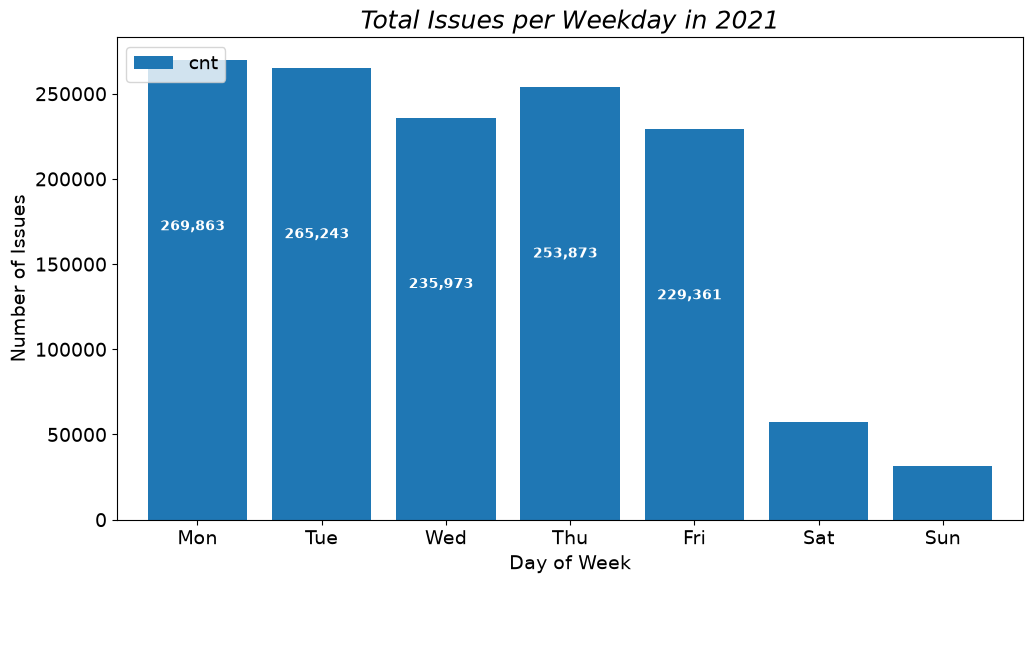

In [53]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import numpy as np

pd_r1 = df_r1.toPandas()

ax = pd_r1[['cnt']].plot(kind='bar',
                         width=0.8,
                         figsize=(11.7, 6.27),
                         legend=False,
                         fontsize=14)

ax.legend(loc=2, prop={'size': 14})
ax.set_xlabel("Day of Week", fontsize=14)
ax.set_ylabel("Number of Issues", fontsize=14)
ax.set_xticklabels(pd_r1.dow_string, rotation='horizontal')
ax.set_title('Total Issues per Weekday in 2021', fontsize=18, fontstyle='italic')

def group(number):
    s = '%d' % number
    groups = []
    while s and s[-1].isdigit():
        groups.append(s[-3:])
        s = s[:-3]
    return s + ','.join(reversed(groups))


y=list(pd_r1.cnt)
counter = 0
for i in y:
    ax.text(counter-0.3, i-100000, str(group(i)), color='white', fontweight='bold')
    counter = counter + 1

plt.show()

## Analysis 2 (Boxplot): distribution of number fines per day of week

In [54]:
sqlContext.registerDataFrameAsTable(df_Issue, "df_Issue")

df_r2 = sqlContext.sql("""
                 SELECT month
                        ,dow_number
                        ,dow_string
                        ,count(*) as cnt
                   FROM df_Issue
                  GROUP BY dow_string
                          ,dow_number
                          ,month
                  ORDER BY month, dow_number
                     """)

pd_r2 = df_r2.toPandas()

f:\GIT_REPOS\Leistungsnachweis-ZHAW\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


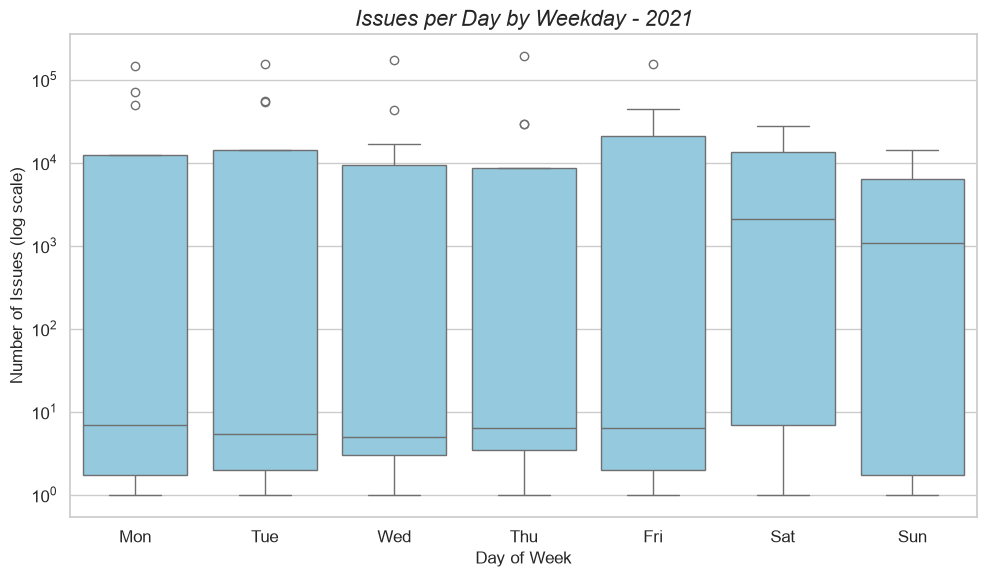

In [56]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns
sns.set(style="whitegrid", color_codes=True)

fig, ax = plt.subplots()
fig.set_size_inches(11.7, 6.27)

# Logarithmic boxplot for comparing weekday distributions across magnitudes.
ax = sns.boxplot(x='dow_string', y='cnt', data=pd_r2, color='skyblue')
ax.set_yscale('log')

ax.set_title("Issues per Day by Weekday - 2021", fontsize=16, fontstyle='italic')
ax.set_xlabel("Day of Week", fontsize=12)
ax.set_ylabel("Number of Issues (log scale)", fontsize=12)
ax.tick_params(labelsize=12)

plt.show()

## Analysis 3 (Barplot): total number fines per daytime (hour) in 2016

In [57]:
sqlContext.registerDataFrameAsTable(df, "df")

df_r3 = sqlContext.sql("""
                 SELECT time_hrs_24
                        ,count(*) as cnt
                   FROM df  
                  WHERE time_hrs_24 >= 0 and time_hrs_24 < 24
                  GROUP BY time_hrs_24
                  ORDER BY time_hrs_24
                     """)

pd_r3 = df_r3.toPandas()

f:\GIT_REPOS\Leistungsnachweis-ZHAW\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


C:\Users\Stephan\AppData\Local\Temp\ipykernel_25776\166488699.py:5: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  ax = pd_r3[['cnt']].plot(kind='bar',


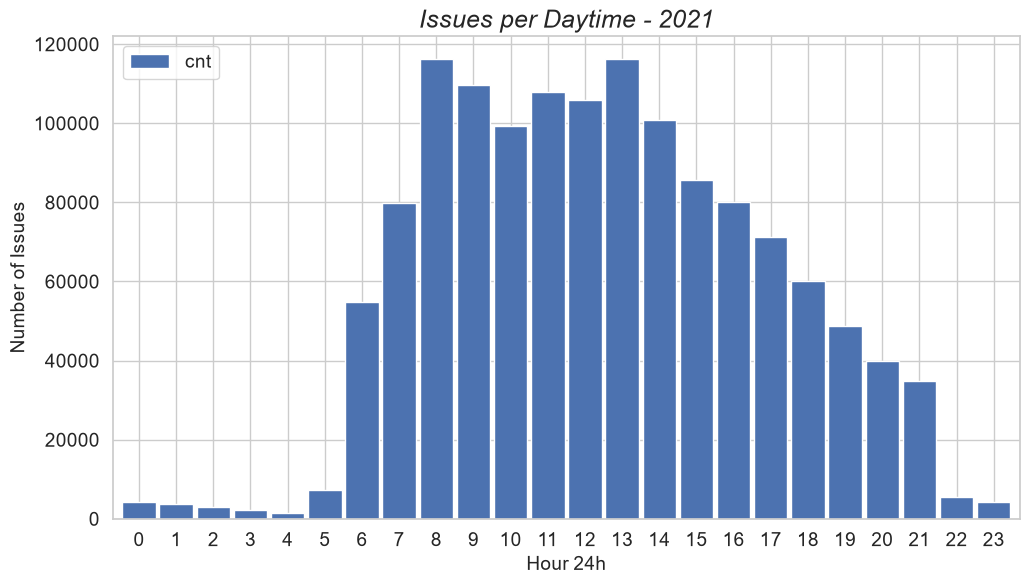

In [61]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import numpy as np

ax = pd_r3[['cnt']].plot(kind='bar',
                         figsize=(11.7, 6.27),
                         width=0.9,
                         legend=False,
                         fontsize=14)

ax.legend(loc=2, prop={'size': 14})
ax.set_xlabel("Hour 24h", fontsize=14)
ax.set_ylabel("Number of Issues", fontsize=14)
ax.set_xticklabels(pd_r3.time_hrs_24, rotation='horizontal')
ax.set_title('Issues per Daytime - 2021', fontsize=18, fontstyle='italic')

plt.show()

## Analysis 4 (Boxplot): distribution of number fines per daytime (hour)

In [59]:
sqlContext.registerDataFrameAsTable(df_Issue, "df_Issue")

df_r4 = sqlContext.sql("""
                 SELECT day
                        ,time_hrs_24
                        ,count(*) as cnt
                   FROM df_Issue
                  WHERE time_hrs_24 >= 0
                  GROUP BY day, time_hrs_24
                  ORDER BY day, time_hrs_24
                     """)

pd_r4 = df_r4.toPandas()

f:\GIT_REPOS\Leistungsnachweis-ZHAW\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


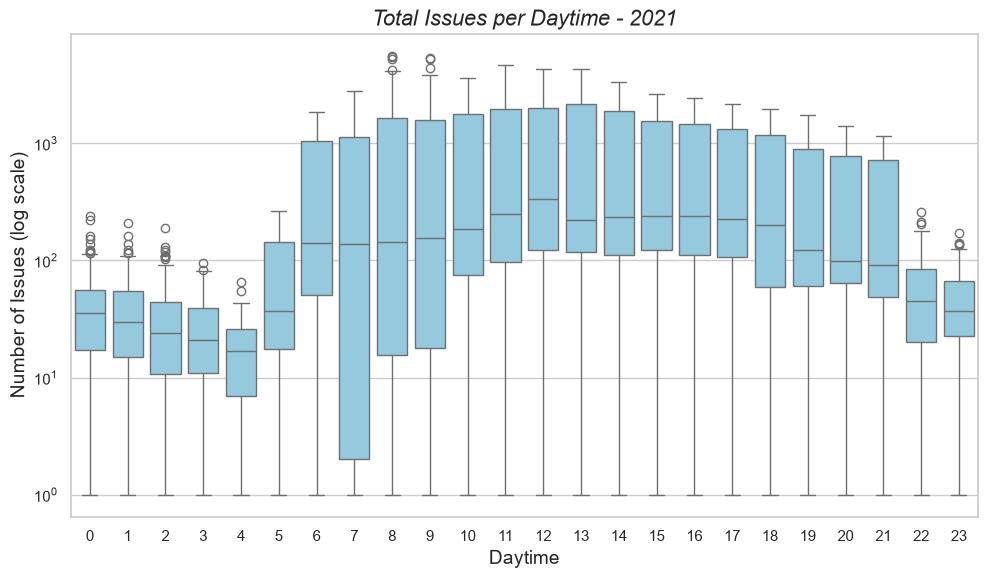

In [60]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns
sns.set(style="whitegrid", color_codes=True)

fig, ax = plt.subplots()
fig.set_size_inches(11.7, 6.27)

# Logarithmic boxplot for daily issue counts by daytime.
ax = sns.boxplot(x='time_hrs_24', y='cnt', data=pd_r4, color='skyblue')
ax.set_yscale('log')

ax.set_title("Total Issues per Daytime - 2021", fontsize=16, fontstyle='italic')
ax.set_xlabel("Daytime", fontsize=14)
ax.set_ylabel("Number of Issues (log scale)", fontsize=14)

plt.show()

## Analysis 5 (Heatmap): distribution of number fines per day of week and daytime (hour) 

In [62]:
sqlContext.registerDataFrameAsTable(df_Issue, "df_Issue")

df_r5 = sqlContext.sql("""
                SELECT dow_number
                        ,dow_string
                        ,time_hrs_24
                        ,avg(cnt) as avg_cnt
                FROM(SELECT  dow_number
                        ,dow_string
                        ,day
                        ,time_hrs_24
                        ,count(*) as cnt
                   FROM df_Issue
                  WHERE time_hrs_24 >= 0
                  GROUP BY day, dow_number, dow_string, time_hrs_24)
                  GROUP BY dow_number, dow_string, time_hrs_24
                  ORDER BY dow_number, dow_string, time_hrs_24
                     """)

pd_r5 = df_r5.toPandas()

f:\GIT_REPOS\Leistungsnachweis-ZHAW\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


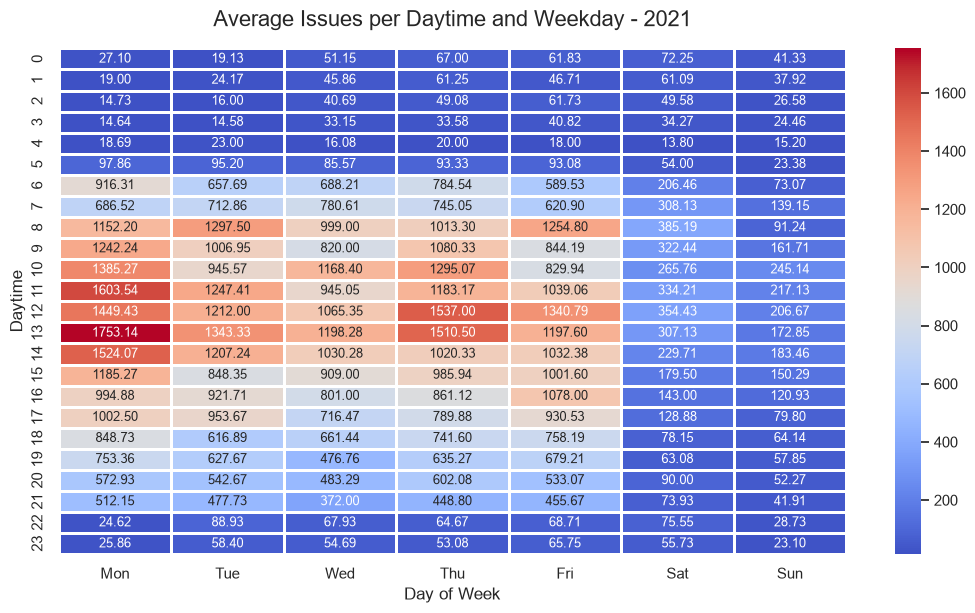

: 

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

midpoint = (pd_r5.avg_cnt.max() - pd_r5.avg_cnt.min()) / 2

result = pd_r5.pivot(index='time_hrs_24', columns='dow_number', values='avg_cnt')
plt.rcParams['font.size'] = 20
fig, ax = plt.subplots()
fig.set_size_inches(12.7, 6.57)
hmap = sns.heatmap(result,
            annot=True,
            fmt=".2f",
            annot_kws={'size':9},
            cmap='coolwarm',
            center=midpoint,
            ax=ax, linewidths=1,
            linecolor='white')

dow_s = pd_r5.dow_string.unique().tolist()
dow_n = pd_r5.dow_number.unique().astype(int).tolist()
dicts = {}
for i in dow_n:
    dicts[dow_n[i-1]] = dow_s[i-1]

hmap.set(xticklabels=dicts.values())
ax.set_title('Average Issues per Daytime and Weekday - 2021', fontsize=16, pad=16)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Daytime')

plt.show()